## example

- We pick a single column where there is very few cells (see example with An in compare_Jterms_layers
- we run the full budget for this point (column) as our mask and try to achieve closure for this individual column
- try to compute the dVdt for this column and all terms
- we will outprint all of these onto some example


In [104]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(450, 90)
RAC2d (40500,)
(100,)


In [105]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [106]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

In [107]:
landmsk = np.zeros((ny,nx))
landmsk[hf1 == 0] = 1
landmsk[hf1 == 1] = np.nan

In [108]:
# ok we defined mymsk, now we need to define the indices in ind where these are selected
# load the JtermsT from the function (see previous configuration of layers)

# not sure if this will be the correct way to load it but we can check
# we will use the bins from the An run so that we have the same thing in both sections
# Paths for the bins in this run
filename = "layers2TH"
boundsT = rdmds(layers_path + filename)
binsTH_edges = boundsT.reshape(boundsT.shape[0])
binsTH_centers = (binsTH_edges[:-1] + binsTH_edges[1:])/2
nT = binsTH_edges.shape[0]-1
print(nT)

filename = "layers1SLT"
boundsS = rdmds(layers_path + filename)
binsSLT_edges = boundsS.reshape(boundsS.shape[0])
binsSLT_centers = (binsSLT_edges[:-1] + binsSLT_edges[1:])/2
nS = binsSLT_edges.shape[0]-1
print(nS)

binwidthT = binsTH_edges[1:] - binsTH_edges[:-1]
print(binwidthT.shape)
binwidthS = binsSLT_edges[1:] - binsSLT_edges[:-1]

binwidthT1 = (binwidthT[:-1] + binwidthT[1:])/2
binwidthS1 = (binwidthS[:-1] + binwidthS[1:])/2

dT,dS = np.meshgrid(binwidthT,binwidthS)
dT = dT.reshape(112,112,1)
dS = dS.reshape(112,112,1)

binmidT = ((boundsT[:-1] + boundsT[1:])/2).reshape(nT)
binmidS = ((boundsS[:-1] + boundsS[1:])/2).reshape(nT)

binmidTp = boundsT[1:-1]
binmidSp = boundsS[1:-1]

Tbin,Sbin = np.meshgrid(binsTH_edges,binsSLT_edges)
Tbincent,Sbincent = np.meshgrid(binsTH_centers,binsSLT_centers)
Tbin2,Sbin2 = np.meshgrid(binmidTp,binmidSp)

112
112
(112,)


In [109]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version

In [110]:
# we know this to be correct from the generation of the horizontal converences of the fields. Let's create these for temperature

from create_aste90_layers import create_layers_totalTHETA,create_layers_totalSALT

dt = 1800
termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=True)
termsS3D = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=True)

In [111]:
# we need to figure out what point we used from the faces 
b = np.zeros((ny,nx))
b2 = get_aste_faces(b,nfx,nfy)
b2.f3[0,0,19] = 1
b3 = aste_faces2compact(b2,nfx,nfy)[0]
iy,ix = np.where(b3 == 1)[0][0],np.where(b3 == 1)[1][0]
print(iy,ix)

150 19


In [112]:
# load the THETA and SALT for this timestep
t2 = int(tsstr[1])
# 'diags/state_3d_set1'
# read theta and salt averages from the t2 timestep (average)
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz,ny,nx)
SALT = SALT.reshape(nz,ny,nx)

In [113]:
# Flatten so we don't have to loop thorugh zyx
mymsk3d = np.zeros((nz,ny,nx))
mymsk3d[:,iy,ix] = 1

In [114]:
def ts_bin_indices(
    T, S,
    binmidT, binmidS,
    order="F",
    mask=None,
    require_finite=True,
    print_samples=20,
):
    """
    For input arrays T and S (any shape), compute 2D (T,S) bin indices using
    searchsorted on bin midpoints (same as your code), and print the indices.

    Returns
    -------
    iT_ok, iS_ok : 1D int arrays
        Bin indices for points that land in valid interior bins.
    ok : 1D bool array
        Mask in flattened space indicating which points are kept.
    """

    T = np.asarray(T)
    S = np.asarray(S)
    if T.shape != S.shape:
        raise ValueError(f"T and S must have the same shape; got {T.shape} vs {S.shape}")

    if mask is None:
        m = np.ones(T.shape, dtype=bool)
    else:
        m = np.asarray(mask).astype(bool)
        if m.shape != T.shape:
            raise ValueError(f"mask must have same shape as T/S; got {m.shape} vs {T.shape}")

    # Flatten like your pipeline
    T_flat = np.ravel(T, order=order)
    S_flat = np.ravel(S, order=order)
    m_flat = np.ravel(m, order=order)

    # Bin lookup (same convention as your snippet)
    iT = np.searchsorted(binmidT, T_flat, side="right") - 1
    iS = np.searchsorted(binmidS, S_flat, side="right") - 1

    nT = len(binmidT)
    nS = len(binmidS)

    ok = m_flat & (iT >= 0) & (iT < nT - 1) & (iS >= 0) & (iS < nS - 1)
    if require_finite:
        ok = ok & np.isfinite(T_flat) & np.isfinite(S_flat)

    iT_ok = iT[ok].astype(int, copy=False)
    iS_ok = iS[ok].astype(int, copy=False)

    # Print unique bins + a few samples
    pairs = np.stack([iT_ok, iS_ok], axis=1) if iT_ok.size else np.empty((0, 2), int)
    uniq, counts = (np.unique(pairs, axis=0, return_counts=True) if pairs.size else (pairs, np.array([], int)))

    # print(f"kept points: {iT_ok.size} / {T_flat.size}")
    # print(f"unique (iT,iS) bins: {uniq.shape[0]}")
    # if uniq.shape[0]:
    #     show = min(print_samples, uniq.shape[0])
    #     print(f"first {show} unique bins (iT,iS) with counts:")
    #     for (it, is_), c in zip(uniq[:show], counts[:show]):
    #         print(f"  ({it:4d}, {is_:4d})  count={c}")
    # else:
    #     print("no points landed in valid interior bins")

    return iT_ok, iS_ok


ts_bin_indices(THETA, SALT,binmidT, binmidS,order="F",mask=mymsk3d,require_finite=True,)

(array([1, 1]), array([84, 84]))

In [115]:
# tmp = np.where(G_Tend != 0)
# iTc, iSc = (tmp[0][0]),(tmp[1][0])  # indices for the cell center THETA

In [116]:
# print the theta at the cell faces
tC = THETA[:,iy,ix]
tE = (THETA[:,iy,ix] + THETA[:,iy,ix+1]) /2   # where we read -ADVx_TH at ix+1
tW = (THETA[:,iy,ix] + THETA[:,iy,ix-1]) /2   # where we read +ADVx_TH at ix
tN = (THETA[:,iy,ix] + THETA[:,iy+1,ix]) /2   # where we read -ADVy_TH at iy+1
tS = (THETA[:,iy,ix] + THETA[:,iy-1,ix]) /2   # where we read +ADVy_TH at iy

# make a new array of THETA faces for this
THETA_facex = np.full((nz,ny,nx),np.nan)
THETA_facex[:,iy,ix] = tW
THETA_facex[:,iy,ix+1] = tE
THETA_facey = np.full((nz,ny,nx),np.nan)
THETA_facey[:,iy,ix] = tS
THETA_facey[:,iy+1,ix] = tN



# now do for salt
sC = SALT[:,iy,ix]
sE = (SALT[:,iy,ix] + SALT[:,iy,ix+1]) /2   # where we read -ADVx_SLT at ix+1
sW = (SALT[:,iy,ix] + SALT[:,iy,ix-1]) /2   # where we read +ADVx_SLT at ix
sN = (SALT[:,iy,ix] + SALT[:,iy+1,ix]) /2   # where we read -ADVy_SLT at iy+1
sS = (SALT[:,iy,ix] + SALT[:,iy-1,ix]) /2   # where we read +ADVy_SLT at iy

# make a new array of SALT faces for this
SALT_facex = np.full((nz,ny,nx),np.nan)
SALT_facex[:,iy,ix] = sW
SALT_facex[:,iy,ix+1] = sE
SALT_facey = np.full((nz,ny,nx),np.nan)
SALT_facey[:,iy,ix] = sS
SALT_facey[:,iy+1,ix] = sN


ts_bin_indices(THETA_facex, SALT_facex,binmidT, binmidS,order="F",mask=mymsk3d,require_finite=True,)



(array([1, 1, 4, 4]), array([83, 84, 18, 18]))

In [117]:
binmidS[82:86]

array([32.625, 32.875, 33.125, 33.375])

In [118]:
SALT_facey[:,iy+1,ix]

array([33.02385712, 33.22032166,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [119]:
SALT_facey[:,iy+1,ix]

array([33.02385712, 33.22032166,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [120]:
binmidT[1:4]

array([-2.20000005, -1.80000001, -1.5       ])

In [121]:
THETA_facey[:,iy+1,ix]

array([-1.80780178, -1.81442577,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [122]:
THETA_facex[:,iy,ix]

array([-1.80865788, -1.80403185, -0.88456899, -0.8793143 ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [123]:
THETA[:,iy,ix-1]

array([-1.79350448, -1.78346968, -1.76913798, -1.75862861,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [124]:
ts_bin_indices(THETA_facey, SALT_facey,binmidT, binmidS,order="F",mask=mymsk3d,require_finite=True,)

(array([4, 4]), array([18, 18]))

In [125]:
# print the face THETA and SALT
mymsk = np.zeros((ny,nx))
mymsk[iy,ix] = 1
np.where(mymsk ==1)

(array([150]), array([19]))

In [126]:
# get the G terms (the ones we need in degC.m^3/s and PSU.m^3/s on the map
# there are only TWO gates for this column -- at the North and West
# both of the two gates have two faces for items entering the bin

file_name = "budg3d_hflux_set2"
meta_budg3d_hflux_set2 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg3d_hflux_set2["fldList"])
varnames = np.array(["ADVx_TH","ADVy_TH","ADVx_SLT","ADVy_SLT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
ADVx_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
ADVy_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
ADVx_SLT,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[2])
ADVy_SLT,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[3])

ADVx_TH = ADVx_TH.reshape((nz,ny,nx))
ADVy_TH = ADVy_TH.reshape((nz,ny,nx))
ADVx_SLT = ADVx_SLT.reshape((nz,ny,nx))
ADVy_SLT = ADVy_SLT.reshape((nz,ny,nx))

In [187]:
print("indexed at iT =",iT[0],"iS =",iS[0])
print()

tmpsumT = 0
for key in termsT3D:
    print(key,np.nansum(termsT3D[key][:2,iy,ix]) , "degC.m^3/s" )
    if key!= "tend":
        tmpsumT += np.nansum(termsT3D[key][:2,iy,ix])

print(np.nansum(termsT3D['tend'][:2,iy,ix]),tmpsumT)

print()

tmpsumS = 0
for key in termsS3D:
    print(key,np.nansum(termsS3D[key][:2,iy,ix]) , "PSU.m^3/s" )
    if key!= "tend":
        tmpsumS += np.nansum(termsS3D[key][:2,iy,ix])

print(np.nansum(termsS3D['tend'][:2,iy,ix]),tmpsumS)


indexed at iT = 1 iS = 84

ADVh -1195.1185829688702 degC.m^3/s
ADVr 0.0 degC.m^3/s
DFhT 10.078493851158122 degC.m^3/s
DFrT 0.0 degC.m^3/s
surf 44.85582463807483 degC.m^3/s
KPP 0.0 degC.m^3/s
tend -1140.1842644880182 degC.m^3/s
-1140.1842644880182 -1140.1842644796372

ADVh 20827.636172519793 PSU.m^3/s
ADVr 0.0 PSU.m^3/s
DFhS 0.30809382444576094 PSU.m^3/s
DFrS 0.0 PSU.m^3/s
surf -7196.1907017086305 PSU.m^3/s
KPP 0.0 PSU.m^3/s
tend 13631.753564946903 PSU.m^3/s
13631.753564946903 13631.753564635608


In [25]:
# print the values at the two gates which exist and we care about here
# WEST (ix) and NORTH (iy+1)
print("West gates indexed at iT = 1 and iS = 83 (top) and iS = 84 (bottom)")
print(ADVx_TH[:2,iy,ix],"degC.m^3/s")
print(ADVx_SLT[:2,iy,ix],"PSU.m^3/s")

print()

print("North gates indexed at iT = 1 and iS = 83 (top) and iS = 84 (bottom)")
print(-ADVy_TH[:2,iy+1,ix],"degC.m^3/s")
print(-ADVy_SLT[:2,iy+1,ix],"PSU.m^3/s")

print()
# these are the same values as above but binned to different T and s.
# do a check for the gates
print(np.nansum(-ADVy_TH[:2,iy+1,ix] + ADVx_TH[:2,iy,ix]))
print(np.nansum(-ADVy_SLT[:2,iy+1,ix] + ADVx_SLT[:2,iy,ix]))

# and these are the same as the values we got in the previous slide (right that makes sense)

West gates indexed at iT = 1 and iS = 83 (top) and iS = 84 (bottom)
[10314.03395862  7891.84578452] degC.m^3/s
[-188480.39923605 -145174.66448811] PSU.m^3/s

North gates indexed at iT = 1 and iS = 83 (top) and iS = 84 (bottom)
[-12731.46343656  -6669.53488955] degC.m^3/s
[232500.18231723 121982.51757945] PSU.m^3/s

-1195.1185829688702
20827.636172519793


In [53]:
# binwidthT1[1]
binmidS[83:86]

array([32.875, 33.125, 33.375])

In [55]:
SALT[0,iy,ix]

33.32093048095703

In [56]:
SALT[1,iy,ix]

33.333656311035156

In [36]:
# binwidthS1[83:85]

In [42]:
# ok, somehow if the gates are creating water at iT=1 and iS = 83, there needs to be destruction in the same zones
# this destruction can come from one of the other terms

dT,dS = 0.4,0.25
# indexed at iT = 1 iS = 84
valsT = np.array([-1195.1185829688702,0.0,10.078493851158122,0.0,44.85582463807483,0.0,-1140.1842644880182])         # degC.m^3/s
Jy = np.zeros((7,111,111))
for i in range(7):
    print(valsT[i])
    Jy[i,1,84] = valsT[i] / dT / dS * 1e-6   # Sv/PSU


valsS = np.array([20827.636172519793,0.0,0.30809382444576094,0.0,-7196.1907017086305,0.0,13631.753564946903])        # PSU.m^3/s
Jx = np.zeros((7,111,111))
for i in range(7):
    Jx[i,1,84] = valsS[i] / dT / dS * 1e-6   # Sv/degC

# the above is how we constructed the J vectors in the layers package output

# now construct the gates
my = np.zeros((2,111,111))  # for West and North, degC.m^3/s
mx = np.zeros((2,111,111))  # for West and North, PSU.m^3/s

my[0,1,83] += 10314.03395862       # degC.m^3/s for West
my[0,1,84] += 7891.84578452
my[1,1,83] += (-12731.46343656)    # degC.m^3/s for North
my[1,1,84] += (-6669.53488955)

mx[0,1,83] += (-188480.39923605)
mx[0,1,84] += (-145174.66448811)
mx[1,1,83] += 232500.18231723
mx[1,1,84] += 121982.51757945

my = my / dT /dS * 1e-6  # Sv/PSU
mx = mx / dT /dS * 1e-6  # Sv/degC


-1195.1185829688702
0.0
10.078493851158122
0.0
44.85582463807483
0.0
-1140.1842644880182


In [149]:
# pick which terms you want included in the TS flux vectors
# if you are "replacing ADVh with gates", then build J from gates-only contributions,
# i.e. exclude ADVh from the J you take divergence of.
iADVh = 0
iADVr, iDFh, iDFr, iSurf, iKPP, iTend = 1,2,3,4,5,6
internal_idx = [iADVr, iDFh, iDFr, iKPP]

# 2D internal TS flux components (111x111)
Jy_internal = np.nansum(Jy[internal_idx, :, :], axis=0)
Jx_internal = np.nansum(Jx[internal_idx, :, :], axis=0)

# cell-centered divergence: d/dT(Jy) + d/dS(Jx)
div_internal = np.zeros((111,111))
print(Jy_internal[:-1, :].shape)
print(Jy_internal[1:, :].shape)
div_internal[1:, :] = (Jy_internal[1:, :] - Jy_internal[:-1, :]) / 0.4 *1e-6
div_internal[:, :-1] += (Jx_internal[:, 1:] - Jx_internal[:, :-1]) / 0.25 *1e-6

(110, 111)
(110, 111)


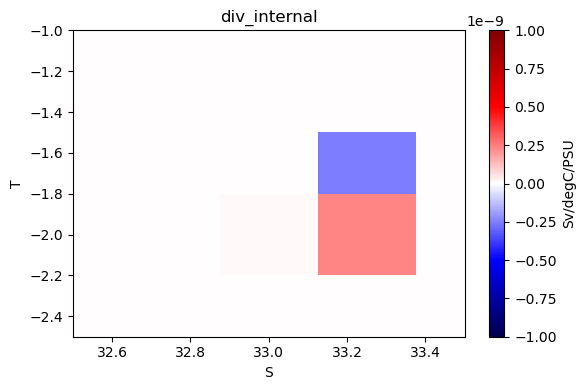

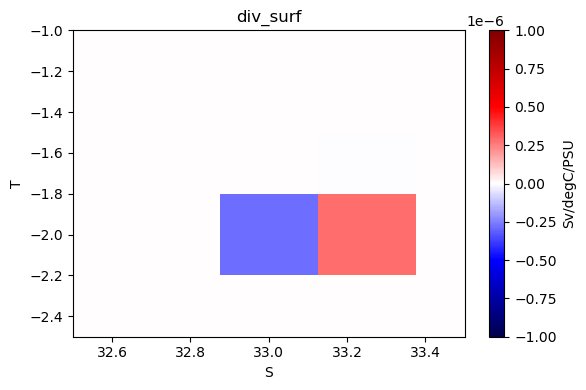

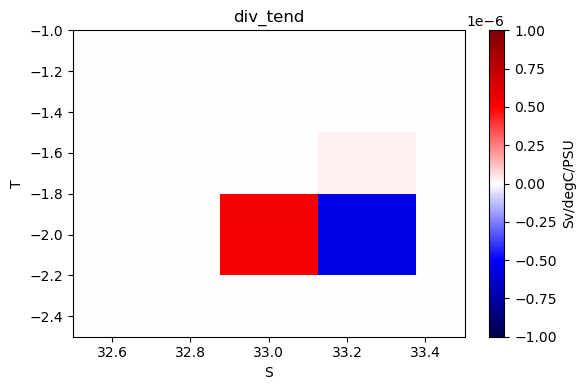

In [155]:
# INTERNAL
plt.figure(figsize=(6,4))
plt.pcolormesh(Sbin2, Tbin2, div_internal.T, cmap='seismic', vmin=-1e-9, vmax=1e-9)
plt.xlim(32.5, 33.5)
plt.ylim(-2.5, -1)
plt.colorbar(label="Sv/degC/PSU")
plt.title("div_internal")
plt.xlabel("S")
plt.ylabel("T")
plt.tight_layout()


# SURFACE
plt.figure(figsize=(6,4))
plt.pcolormesh(Sbin2, Tbin2, div_surf.T, cmap='seismic', vmin=-1e-6, vmax=1e-6)
plt.xlim(32.5, 33.5)
plt.ylim(-2.5, -1)
plt.colorbar(label="Sv/degC/PSU")
plt.title("div_surf")
plt.xlabel("S")
plt.ylabel("T")
plt.tight_layout()


# TOTAL TEND
plt.figure(figsize=(6,4))
plt.pcolormesh(Sbin2, Tbin2, div_tend.T, cmap='seismic', vmin=-1e-6, vmax=1e-6)
plt.xlim(32.5, 33.5)
plt.ylim(-2.5, -1)
plt.colorbar(label="Sv/degC/PSU")
plt.title("div_tend")
plt.xlabel("S")
plt.ylabel("T")
plt.tight_layout()

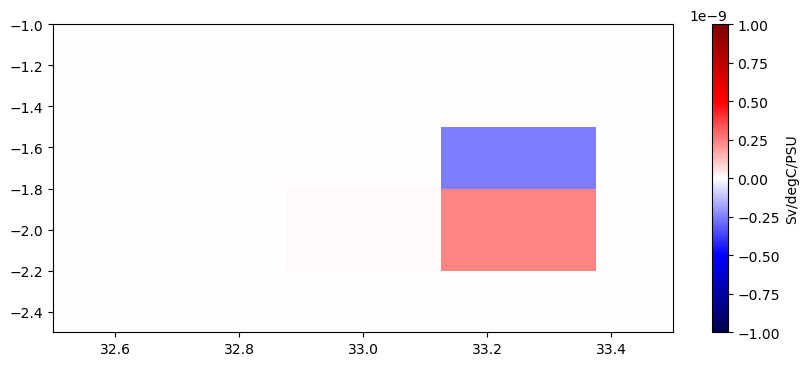

In [152]:
plt.pcolormesh(Sbin2,Tbin2,div_internal.T,cmap='seismic',vmin=-1e-9,vmax=1e-9)
plt.xlim(32.5,33.5)
plt.ylim(-2.5,-1)
plt.colorbar(label="Sv/degC/PSU")

In [153]:
# pick which terms you want included in the TS flux vectors
# if you are "replacing ADVh with gates", then build J from gates-only contributions,
# i.e. exclude ADVh from the J you take divergence of.
iADVh = 0
iADVr, iDFh, iDFr, iSurf, iKPP, iTend = 1,2,3,4,5,6
internal_idx = [iADVr, iDFh, iDFr, iKPP]

# 2D internal TS flux components (111x111)
Jy_internal = np.nansum(Jy[internal_idx, :, :], axis=0)
Jx_internal = np.nansum(Jx[internal_idx, :, :], axis=0)

# cell-centered divergence: d/dT(Jy) + d/dS(Jx)
div_internal = np.zeros((111,111))
print(Jy_internal[:-1, :].shape)
print(Jy_internal[1:, :].shape)
div_internal[1:, :] = (Jy_internal[1:, :] - Jy_internal[:-1, :]) / 0.4 * 1e-6
div_internal[:, :-1] += (Jx_internal[:, 1:] - Jx_internal[:, :-1]) / 0.25 * 1e-6


# surface (as flux-vector contribution, same operator)
surf_idx = [iSurf]

# 2D surface TS flux components (111x111)
Jy_surf = np.nansum(Jy[surf_idx, :, :], axis=0)
Jx_surf = np.nansum(Jx[surf_idx, :, :], axis=0)

# cell-centered divergence of surface contribution
div_surf = np.zeros((111,111))
print(Jy_surf[:-1, :].shape)
print(Jy_surf[1:, :].shape)
div_surf[1:, :] = (Jy_surf[1:, :] - Jy_surf[:-1, :]) / 0.4 * 1e-6
div_surf[:, :-1] += (Jx_surf[:, 1:] - Jx_surf[:, :-1]) / 0.25 * 1e-6


# total tendency (as flux-vector contribution, same operator)
tend_idx = [iTend]

# 2D tendency TS flux components (111x111)
Jy_tend = np.nansum(Jy[tend_idx, :, :], axis=0)
Jx_tend = np.nansum(Jx[tend_idx, :, :], axis=0)

# cell-centered divergence of total tendency contribution
div_tend = np.zeros((111,111))
print(Jy_tend[:-1, :].shape)
print(Jy_tend[1:, :].shape)
div_tend[1:, :] = (Jy_tend[1:, :] - Jy_tend[:-1, :]) / 0.4 * 1e-6
div_tend[:, :-1] += (Jx_tend[:, 1:] - Jx_tend[:, :-1]) / 0.25 * 1e-6

(110, 111)
(110, 111)
(110, 111)
(110, 111)
(110, 111)
(110, 111)


In [ ]:
fig = plt.figure()

ax 

(-2.0, -1.0)

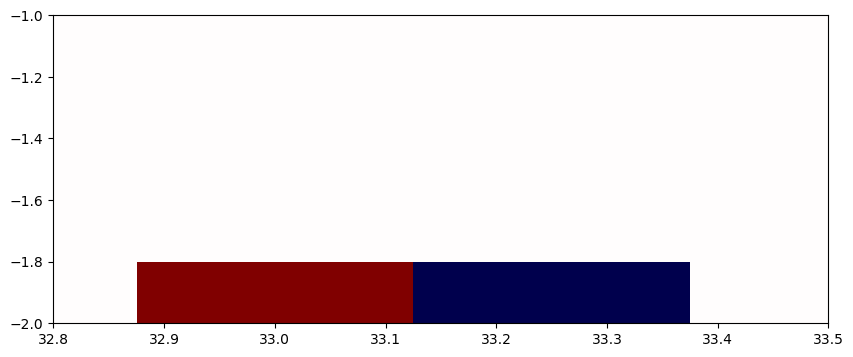

In [101]:
plt.pcolormesh(Sbin2,Tbin2,(mx[0]+mx[1]).T,cmap='seismic',vmin=-.1,vmax=.1)
plt.xlim(32.8,33.5)
plt.ylim(-2,-1)

(-2.0, -1.0)

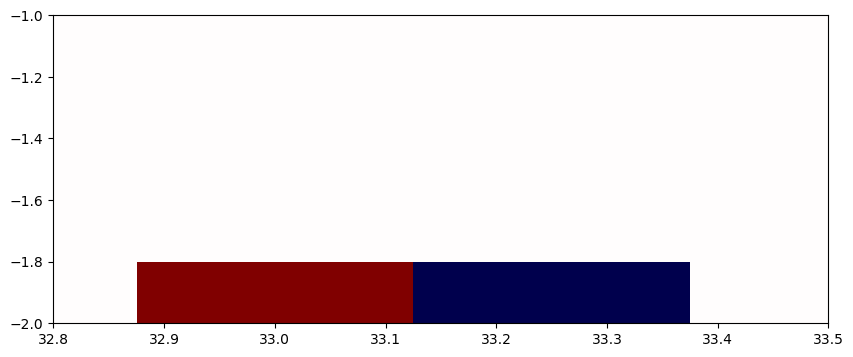

In [102]:
plt.pcolormesh(Sbin2,Tbin2,(mx[0]+mx[1]+my[0]+my[1]).T,cmap='seismic',vmin=-.1,vmax=.1)
plt.xlim(32.8,33.5)
plt.ylim(-2,-1)

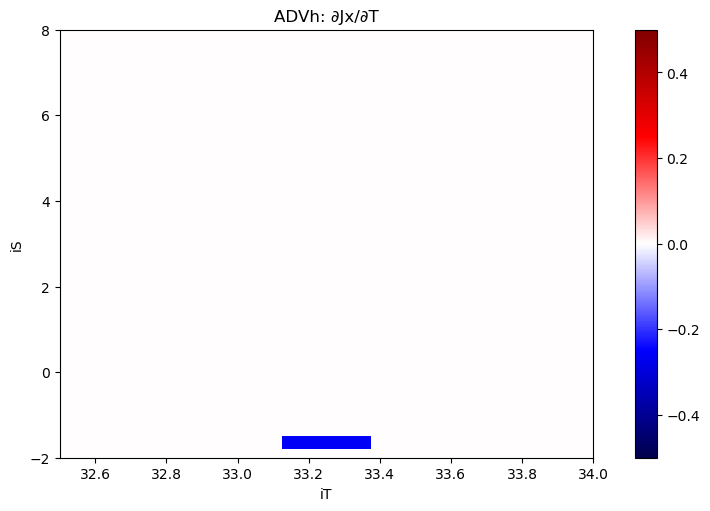

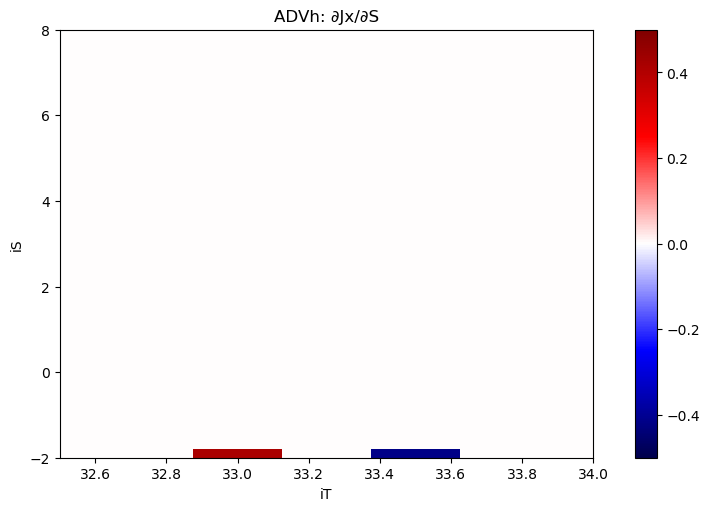

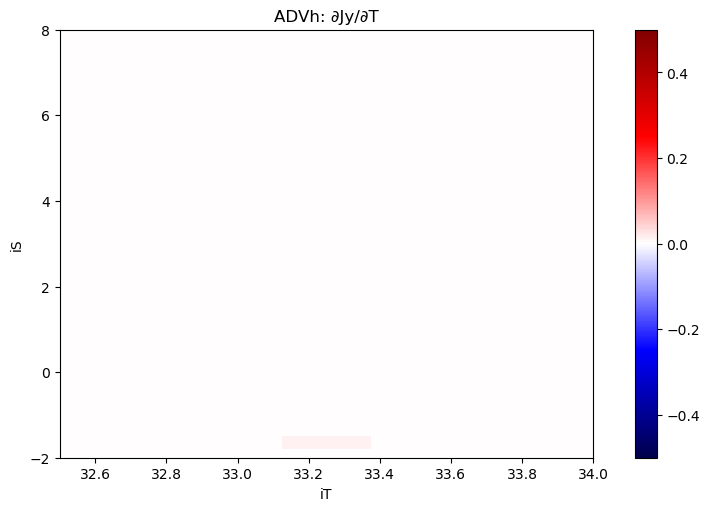

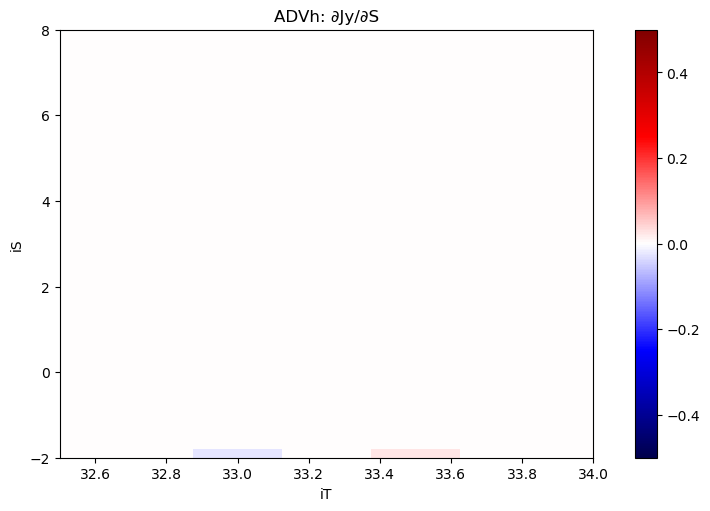

In [79]:
# ---------------------------------------
# Given: single-bin "J components" fields
# ---------------------------------------
dT, dS = 0.4, 0.25

# order: [ADVh, ADVr, DFh, DFr, surf, KPP, tend]
names = ["ADVh","ADVr","DFh","DFr","surf","KPP","tend"]

valsT = np.array([
    -1195.1185829688702, 0.0, 10.078493851158122, 0.0, 44.85582463807483, 0.0, -1140.1842644880182
])  # degC*m^3/s

valsS = np.array([
    20827.636172519793, 0.0, 0.30809382444576094, 0.0, -7196.1907017086305, 0.0, 13631.753564946903
])  # PSU*m^3/s

# Construct J fields (as you did)
Jy = np.zeros((7,111,111))  # "Sv/PSU" (per your construction)
Jx = np.zeros((7,111,111))  # "Sv/degC"

for i in range(7):
    Jy[i,1,84] = valsT[i] / dT / dS * 1e-6
    Jx[i,1,84] = valsS[i] / dT / dS * 1e-6

# ---------------------------------------------------------
# Gradient of J (∂J/∂T, ∂J/∂S) on the TS index grid
# ---------------------------------------------------------
# Convention: axis 1 = iT, axis 2 = iS
# "grad J" typically means you want:
#  - dJx/dT and dJx/dS
#  - dJy/dT and dJy/dS
#
# WARNING: Because your J fields are nonzero at only one TS bin,
# gradients will just show a stencil artifact around that bin.

def grad_field(F, dT, dS):
    # F: (nT,nS)
    dFdT = np.gradient(F, dT, axis=0)   # derivative along iT
    dFdS = np.gradient(F, dS, axis=1)   # derivative along iS
    return dFdT, dFdS

# Compute grads per term
grads = {}
for i, nm in enumerate(names):
    dJx_dT, dJx_dS = grad_field(Jx[i], dT, dS)
    dJy_dT, dJy_dS = grad_field(Jy[i], dT, dS)
    grads[nm] = {
        "dJx_dT": dJx_dT, "dJx_dS": dJx_dS,
        "dJy_dT": dJy_dT, "dJy_dS": dJy_dS
    }

# ---------------------------------------------------------
# Plotting helper (TS index space)
# ---------------------------------------------------------
def plot_ts(field, title, vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(7,5), constrained_layout=True)
    im = ax.pcolormesh(Sbin2,Tbin2,field.T, cmap="seismic", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("iT")
    ax.set_ylabel("iS")
    ax.set_xlim(32.5,34)
    ax.set_ylim(-2,8)
    plt.colorbar(im, ax=ax)
    return fig, ax

# ---------------------------------------------------------
# Example: plot grad J for one term (ADVh) and one component (Jx)
# ---------------------------------------------------------
term_to_plot = "ADVh"

plot_ts(grads[term_to_plot]["dJx_dT"], f"{term_to_plot}: ∂Jx/∂T", vmin=-0.5, vmax=0.5)
plot_ts(grads[term_to_plot]["dJx_dS"], f"{term_to_plot}: ∂Jx/∂S", vmin=-0.5, vmax=0.5)
plot_ts(grads[term_to_plot]["dJy_dT"], f"{term_to_plot}: ∂Jy/∂T", vmin=-0.5, vmax=0.5)
plot_ts(grads[term_to_plot]["dJy_dS"], f"{term_to_plot}: ∂Jy/∂S", vmin=-0.5, vmax=0.5)

plt.show()

# ---------------------------------------------------------
# If you want all terms, loop and plot (will make many figures)
# ---------------------------------------------------------
# for nm in names:
#     plot_ts(grads[nm]["dJx_dT"], f"{nm}: ∂Jx/∂T")
#     plot_ts(grads[nm]["dJx_dS"], f"{nm}: ∂Jx/∂S")
#     plot_ts(grads[nm]["dJy_dT"], f"{nm}: ∂Jy/∂T")
#     plot_ts(grads[nm]["dJy_dS"], f"{nm}: ∂Jy/∂S")
# plt.show()

0.2603454521564974
0.0
3.8511728055720115e-06
0.0
-0.08995238377135786
0.0
0.17039691956183622


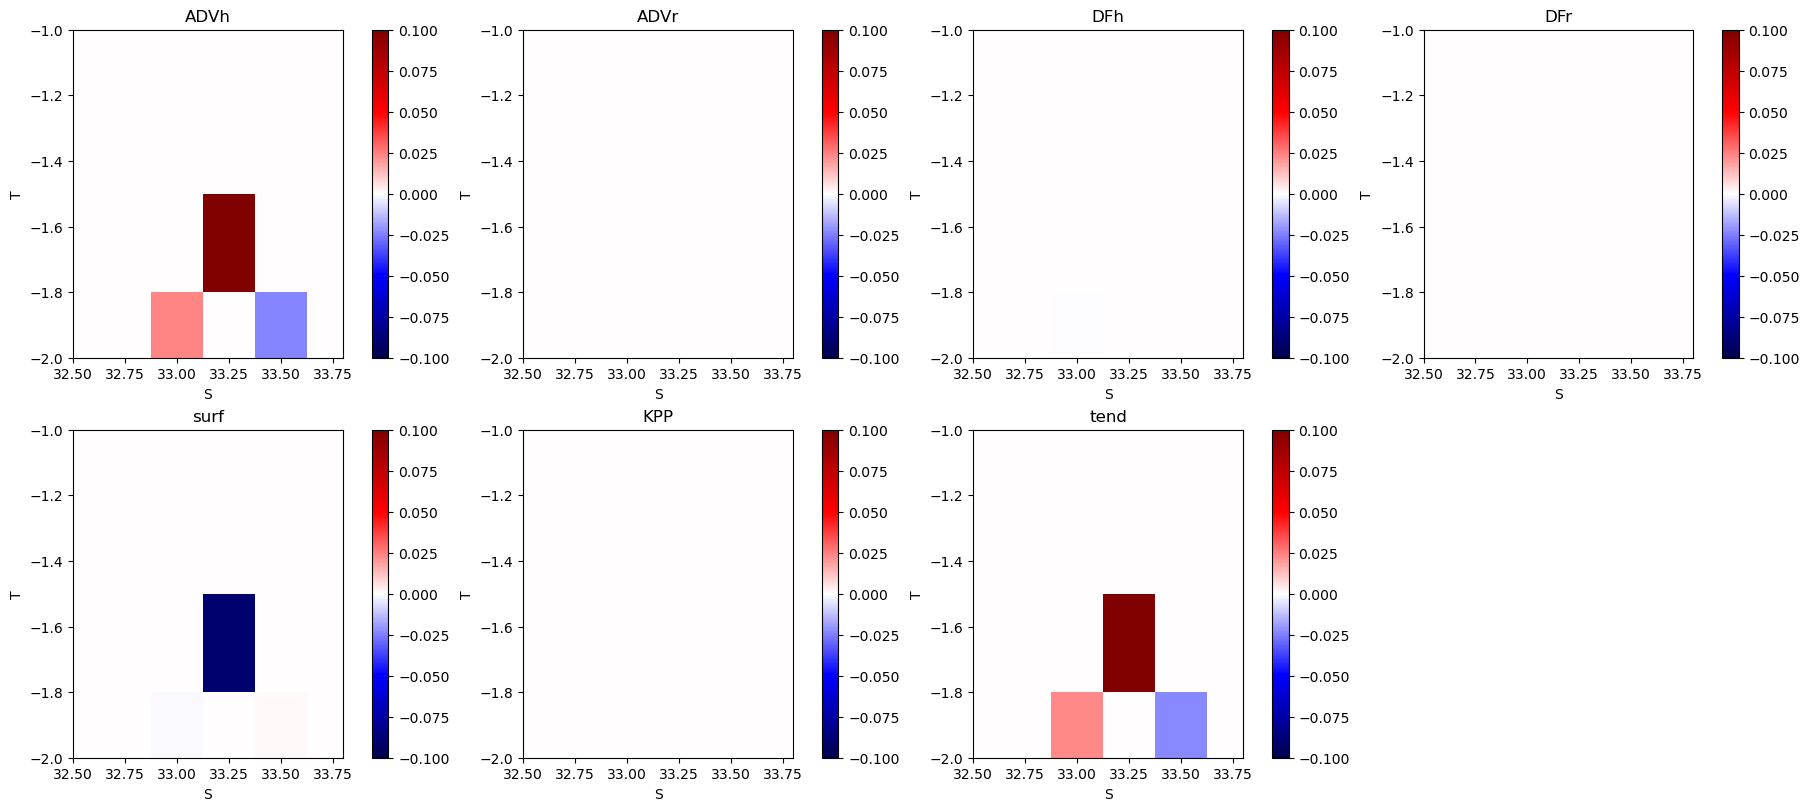

In [103]:
# try to show the dVdt as a result of internal terms

dT, dS = 0.4, 0.25
names = ["ADVh","ADVr","DFh","DFr","surf","KPP","tend"]  # match your term order

fig, axs = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)
axs = axs.ravel()

# set consistent color limits (optional); otherwise comment these out
vmin, vmax = -.1, .1  # adjust to your units

for i, nm in enumerate(names):
    # divergence on TS centers (nT,nS)
    dJx_dT = np.gradient(Jx[i], dT, axis=0)  # Jx shape here should be (nT,nS)
    dJy_dS = np.gradient(Jy[i], dS, axis=1)
    div = dJx_dT + dJy_dS
    print(np.nansum(div))

    ax = axs[i]
    pm = ax.pcolormesh(Sbin2, Tbin2, -div.T, shading="auto",
                       cmap="seismic", vmin=vmin, vmax=vmax)
    ax.set_title(nm)
    ax.set_xlabel("S")
    ax.set_ylabel("T")
    ax.set_xlim(32.5,33.8)
    ax.set_ylim(-2,-1)
    fig.colorbar(pm, ax=ax)

# hide the 8th panel if you only have 7 terms
axs[-1].axis("off")

plt.show()

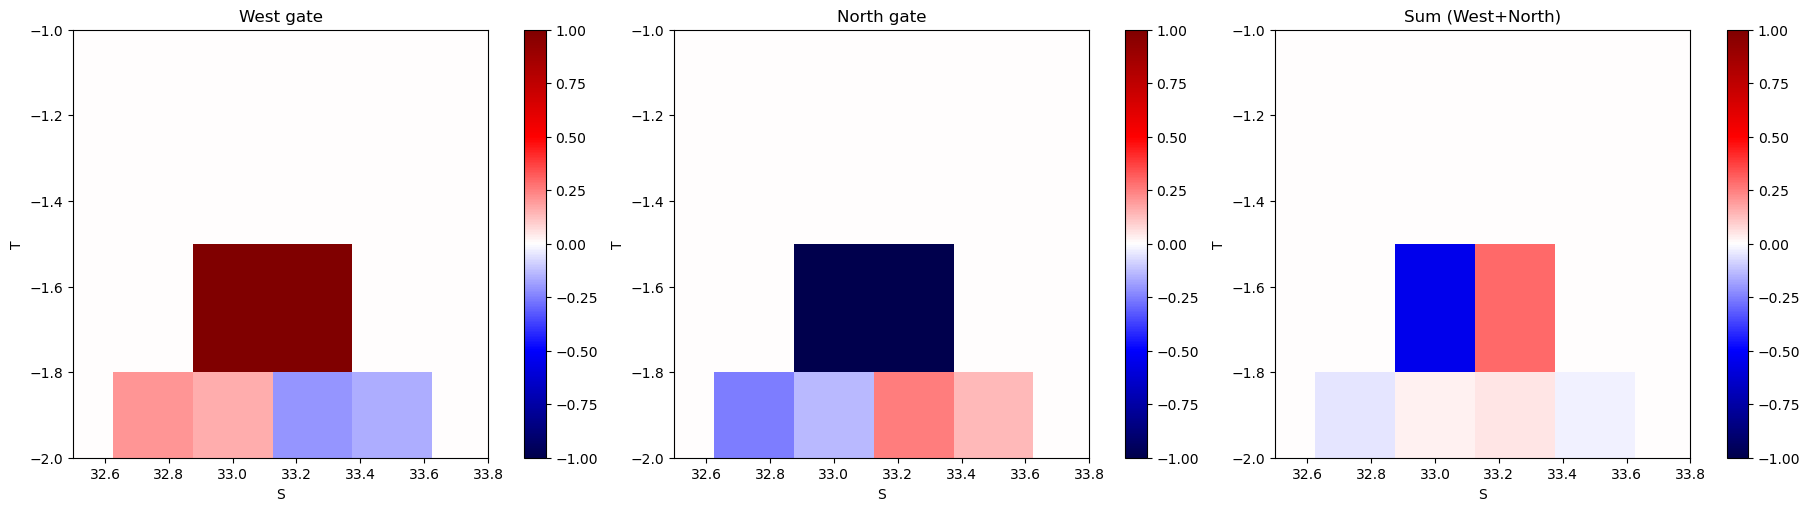

In [89]:
# Assumes:
#   mx, my have shape (2, nT, nS) where index 0=West, 1=North
#   Sbin2, Tbin2 are bin EDGES for pcolormesh with shapes (nS+1,) and (nT+1,)
#   dT, dS are TS bin widths
# Convention (same as before):
#   div = ∂(Jx)/∂T + ∂(Jy)/∂S
#   axis 0 = T, axis 1 = S for each 2D map

dT, dS = 0.4, 0.25
gate_names = ["West gate", "North gate", "Sum (West+North)"]

def divergence(Jx2d, Jy2d, dT=0.4, dS=0.25):
    dJx_dT = np.gradient(Jx2d, dT, axis=0)
    dJy_dS = np.gradient(Jy2d, dS, axis=1)
    return dJx_dT + dJy_dS

# Build the three gate cases: West, North, Sum
mx_list = [mx[0], mx[1], mx[0] + mx[1]]
my_list = [my[0], my[1], my[0] + my[1]]

fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

vmin, vmax = -1, 1  # adjust for your units

for ax, name, Jx2d, Jy2d in zip(axs, gate_names, mx_list, my_list):
    div = divergence(Jx2d, Jy2d, dT, dS)
    pm = ax.pcolormesh(Sbin2, Tbin2, div.T, shading="auto",
                       cmap="seismic", vmin=vmin, vmax=vmax)
    ax.set_title(name)
    ax.set_xlabel("S")
    ax.set_ylabel("T")
    
    ax.set_xlim(32.5,33.8)
    ax.set_ylim(-2,-1)
    fig.colorbar(pm, ax=ax)

plt.show()

In [90]:
# do a local div here for Jy and Jx
np.nansum(Jy[1:-1])   # Sv/PSU

0.0005493431848923294

In [91]:
np.nansum(Jx[1:-1])   # Sv/degC

-0.07195882607884184

In [71]:
# what is the "internal transformation value" at iT=1, iS = 84
int_Jy = np.zeros((111,111))
int_Jy[1,84] = np.sum(Jy[1:-1])  # sum ADVr -- DF   Sv/PSU
# need to differentiate by dT (axis 0)

int_Jx = np.zeros((111,111))
int_Jx[1,84] = np.sum(Jx[1:-1])  # sum ADVr -- DF   Sv/degC
# need to differentiate by dS (axis 1)

# divJ = (int_Jy[:-1,:] - int_Jy[1:,:])/dT + (int_Jx[:,:-1] - int_Jx[:,1:])/dS    # Sv/degC/PSU

In [72]:
# plt.pcolormesh(Sbin2,Tbin2,int_Jy.T,cmap="seismic",vmin=-.001,vmax=0.001)
# plt.colorbar()

In [43]:
# can we achieve closure with just the Jy and Jx terms?
# np.nansum(Jy[:-1])
# np.nansum(Jy[-1]) 

# yes, because by construction these things are the same

-0.011401842644796371

In [46]:
dT, dS = 0.4, 0.25

def dvdt_from_TS_terms(Ftheta, FS, dT=0.4, dS=0.25):
    # m^3/s
    return -(Ftheta/dT + FS/dS)

# ----------------------------
# Your printed (cell-center binned) terms at iT=1,iS=84
# order: [ADVh, ADVr, DFh, DFr, surf, KPP, tend]
# ----------------------------
valsT = np.array([
    -1195.1185829688702, 0.0, 10.078493851158122, 0.0, 44.85582463807483, 0.0,
    -1140.1842644880182
])  # degC m^3/s

valsS = np.array([
    20827.636172519793, 0.0, 0.30809382444576094, 0.0, -7196.1907017086305, 0.0,
    13631.753564946903
])  # PSU m^3/s

# ----------------------------
# Gates (your my/mx construction) in native units first
# my_raw: degC m^3/s, mx_raw: PSU m^3/s
# ----------------------------
my_raw = np.zeros((2,111,111))  # [West, North] for temperature-like tracer volume transport
mx_raw = np.zeros((2,111,111))  # [West, North] for salinity-like tracer volume transport

# West gate (top iS=83, bottom iS=84)
my_raw[0,1,83] += 10314.03395862
my_raw[0,1,84] +=  7891.84578452
mx_raw[0,1,83] += -188480.39923605
mx_raw[0,1,84] += -145174.66448811

# North gate (already with your sign convention: -ADVy)
my_raw[1,1,83] += -12731.46343656
my_raw[1,1,84] +=  -6669.53488955
mx_raw[1,1,83] += 232500.18231723
mx_raw[1,1,84] += 121982.51757945

# Net horizontal convergence from gates (this replaces ADVh completely)
F_gates_T = np.nansum(my_raw)   # degC m^3/s
F_gates_S = np.nansum(mx_raw)   # PSU m^3/s

# ----------------------------
# Build the budget WITHOUT ADVh
# ----------------------------
# Internal (non-advective) terms you actually have here:
F_int_T = valsT[2] + valsT[4]   # DFhT + surf (ADVr/DFr/KPP are zero)
F_int_S = valsS[2] + valsS[4]   # DFhS + surf

DV_gates = dvdt_from_TS_terms(F_gates_T, F_gates_S, dT, dS)
DV_int   = dvdt_from_TS_terms(F_int_T,   F_int_S,   dT, dS)

# Tendency from tend (cell-center binned)
DV_tend  = dvdt_from_TS_terms(valsT[6], valsS[6], dT, dS)

print("Gate net convergence equals ADVh? (degC, PSU):", F_gates_T, F_gates_S)
print("Original ADVh (degC, PSU):", valsT[0], valsS[0])
print()

print("DV_tend:", DV_tend)
print("DV_gates:", DV_gates)
print("DV_internal (DFh+surf):", DV_int)
print("DV_gates + DV_internal:", DV_gates + DV_int)
print("closure error (DV_tend - sum):", DV_tend - (DV_gates + DV_int))

# ----------------------------
# Optional: TS “maps” for plotting (cell-center framework)
# One nonzero bin at (iT=1,iS=84), gates folded into that same bin for closure.
# ----------------------------
nT, nS = 111, 111
DV_tend_map = np.zeros((nT,nS))
DV_gate_map = np.zeros((nT,nS))
DV_int_map  = np.zeros((nT,nS))

DV_tend_map[1,84] = DV_tend
DV_gate_map[1,84] = DV_gates
DV_int_map[1,84]  = DV_int

# DV_tend_map should equal DV_gate_map + DV_int_map at (1,84)

Gate net convergence equals ADVh? (degC, PSU): -1195.118582969997 20827.636172520055
Original ADVh (degC, PSU): -1195.1185829688702 20827.636172519793

DV_tend: -51676.55359856757
DV_gates: -80322.74823265523
DV_internal (DFh+surf): 28646.194635313655
DV_gates + DV_internal: -51676.55359734157
closure error (DV_tend - sum): -1.2259988579899073e-06


In [29]:
# is there a way we can manually create the dvdt, assuming these were created correctly?

# we would need G (taken from the above) to be normalized by binwidthT and binwidthS already, to get the vector J
# this is what we did when we made the pcolormesh


In [ ]:
# can we make some kind of manual TS diagrams to show this
# somehow when we take the divergence of the J vectors
Jy = np.zeros((nTm1,nSm1))
Jy[]

In [192]:
# we need to take diverence at the gates
dT = 0.4
dS = 0.25

def dvdt_from_TS_terms(Ftheta, FS, dT=0.4, dS=0.25):
    return -(Ftheta/dT + FS/dS)  # m^3/s

# ---- pull your single-bin numbers (already summed over k=0..1) ----
F_gates_T = np.nansum(-ADVy_TH[:2,iy+1,ix] + ADVx_TH[:2,iy,ix])
F_gates_S = np.nansum(-ADVy_SLT[:2,iy+1,ix] + ADVx_SLT[:2,iy,ix])

F_surf_T  = np.nansum(termsT3D["surf"][:2,iy,ix])
F_surf_S  = np.nansum(termsS3D["surf"][:2,iy,ix])

F_mix_T = (np.nansum(termsT3D["DFhT"][:2,iy,ix]) +
           np.nansum(termsT3D["DFrT"][:2,iy,ix]) +
           np.nansum(termsT3D["KPP"][:2,iy,ix]))
F_mix_S = (np.nansum(termsS3D["DFhS"][:2,iy,ix]) +
           np.nansum(termsS3D["DFrS"][:2,iy,ix]) +
           np.nansum(termsS3D["KPP"][:2,iy,ix]))

F_tend_T  = np.nansum(termsT3D["tend"][:2,iy,ix])
F_tend_S  = np.nansum(termsS3D["tend"][:2,iy,ix])

# ---- convert to m^3/s ----
DV_gates = dvdt_from_TS_terms(F_gates_T, F_gates_S, dT, dS)
DV_surf  = dvdt_from_TS_terms(F_surf_T,  F_surf_S,  dT, dS)
DV_mix   = dvdt_from_TS_terms(F_mix_T,   F_mix_S,   dT, dS)
DV_tend  = dvdt_from_TS_terms(F_tend_T,  F_tend_S,  dT, dS)

print("DV_tend:", DV_tend)
print("DV_gates+DV_surf+DV_mix:", DV_gates + DV_surf + DV_mix)

# ---- build TS maps (zeros except your bin) ----
DV_tend_map  = np.zeros((nT, nS))
DV_mix_map   = np.zeros((nT, nS))
DV_surf_map  = np.zeros((nT, nS))
DV_other_map = np.zeros((nT, nS))  # "internal processes" = gates here

iT0, iS0 = iT[0], iS[0]
DV_tend_map[iT0, iS0]  = DV_tend
DV_mix_map[iT0, iS0]   = DV_mix
DV_surf_map[iT0, iS0]  = DV_surf
DV_other_map[iT0, iS0] = DV_gates  # because other nonmixing nonsurf terms are zero

# Plot each map with pcolormesh/imshow on your TS axes.

DV_tend: -51676.55359856757
DV_gates+DV_surf+DV_mix: -51676.55359734335


In [193]:
DV_internal = DV_tend - DV_surf - DV_mix

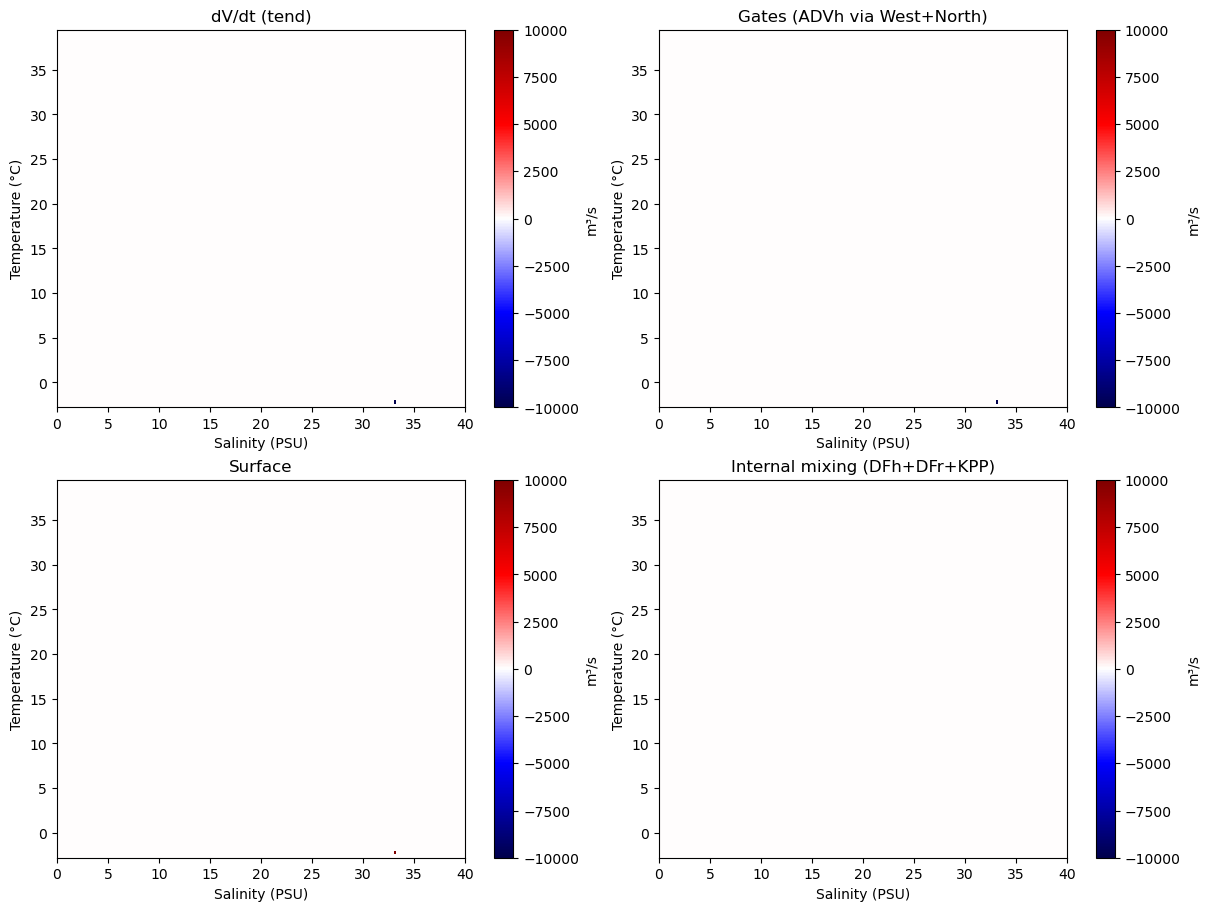

In [203]:

# ---- after you build DV_*_map arrays ----
# DV_tend_map, DV_mix_map, DV_surf_map, DV_other_map have shape (nT, nS)
# T_edges has shape (nT+1,), S_edges has shape (nS+1,)

def plot_ts_maps(Tbin, Sbin, maps, titles):
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
    axs = axs.ravel()

    for ax, M, title in zip(axs, maps, titles):
        pm = ax.pcolormesh(Sbin, Tbin, M.T, shading="auto",cmap='seismic',vmin=-1e4,vmax=1e4)  # x=S, y=T
        ax.set_title(title)
        ax.set_xlabel("Salinity (PSU)")
        ax.set_ylabel("Temperature (°C)")
        plt.colorbar(pm, ax=ax, label="m³/s")

    return fig, axs

maps   = [DV_tend_map, DV_other_map, DV_surf_map, DV_mix_map]
titles = ["dV/dt (tend)", "Gates (ADVh via West+North)", "Surface", "Internal mixing (DFh+DFr+KPP)"]

fig, axs = plot_ts_maps(Tbin, Sbin, maps, titles)
plt.show()